Fit the Model

In [52]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import librosa
from scipy.special import softmax
from scipy import stats
from scipy.signal import find_peaks

In [53]:
df = pd.read_csv("TTLCONS.csv")
df.head()

,observation_date,TTLCONS
0,1993-01-01,458080
1,1993-02-01,462967
2,1993-03-01,458399
3,1993-04-01,469425
4,1993-05-01,468998


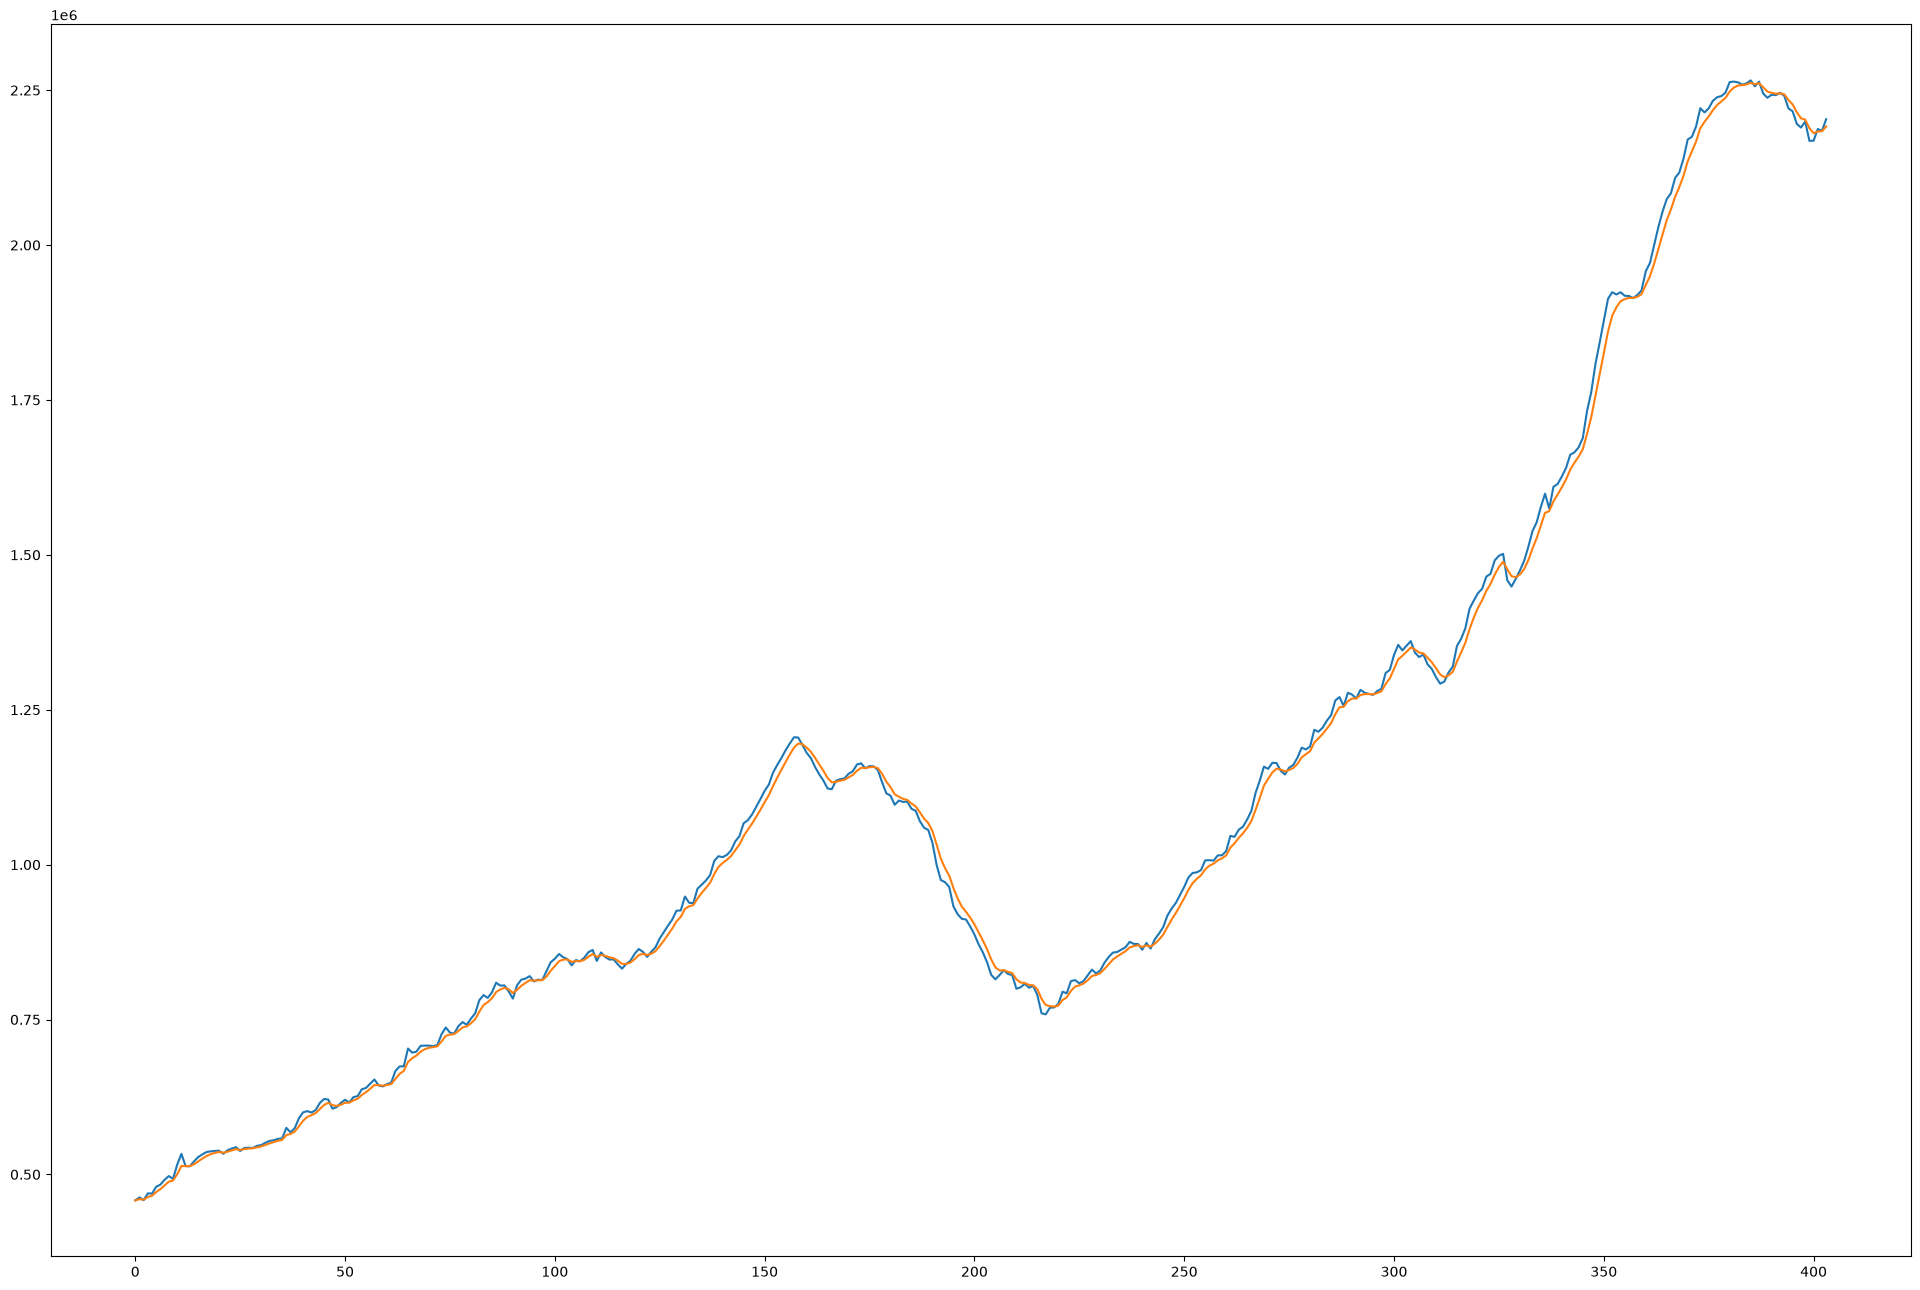

In [54]:
y = df['TTLCONS']
z = y.copy() 
i = 1
while (i < len(y)):
    z[i] = np.ceil(z[i - 1] + 0.4 * ( z[i] - z[i-1])) # LOW PASS FILTER \ ALPHA FILTER 
    i += 1 





n = len(y)
t = np.arange(n)
plt.figure(figsize = (24,16))
plt.plot(t, y)
plt.plot(t,z)
plt.show()

In [55]:
s1_grid = np.arange(140, 181)
s2_grid = np.arange(200, 241)
X = np.zeros((n, 4))
rss = np.full((len(s1_grid) * len(s2_grid), 3), np.inf)

i = 0
for s1 in s1_grid:
    for s2 in s2_grid:
        if s1 < s2:
            X[:, 0] = 1
            X[:, 1] = t
            X[:, 2] = np.maximum(t - s1, 0)
            X[:, 3] = np.maximum(t - s2, 0)
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            rss_val = np.sum((y - X @ beta)**2)
            rss[i] = [rss_val, s1, s2]
            i += 1

rss_min, s1_hat, s2_hat = rss[np.argmin(rss[:, 0])]

print(f"Point estimates: s1 = {int(s1_hat)}, s2 = {int(s2_hat)}")

Point estimates: s1 = 173, s2 = 226


Part B

const    425942.142332
x1         4207.335015
x2       -12677.480762
x3        17516.500265
dtype: float64


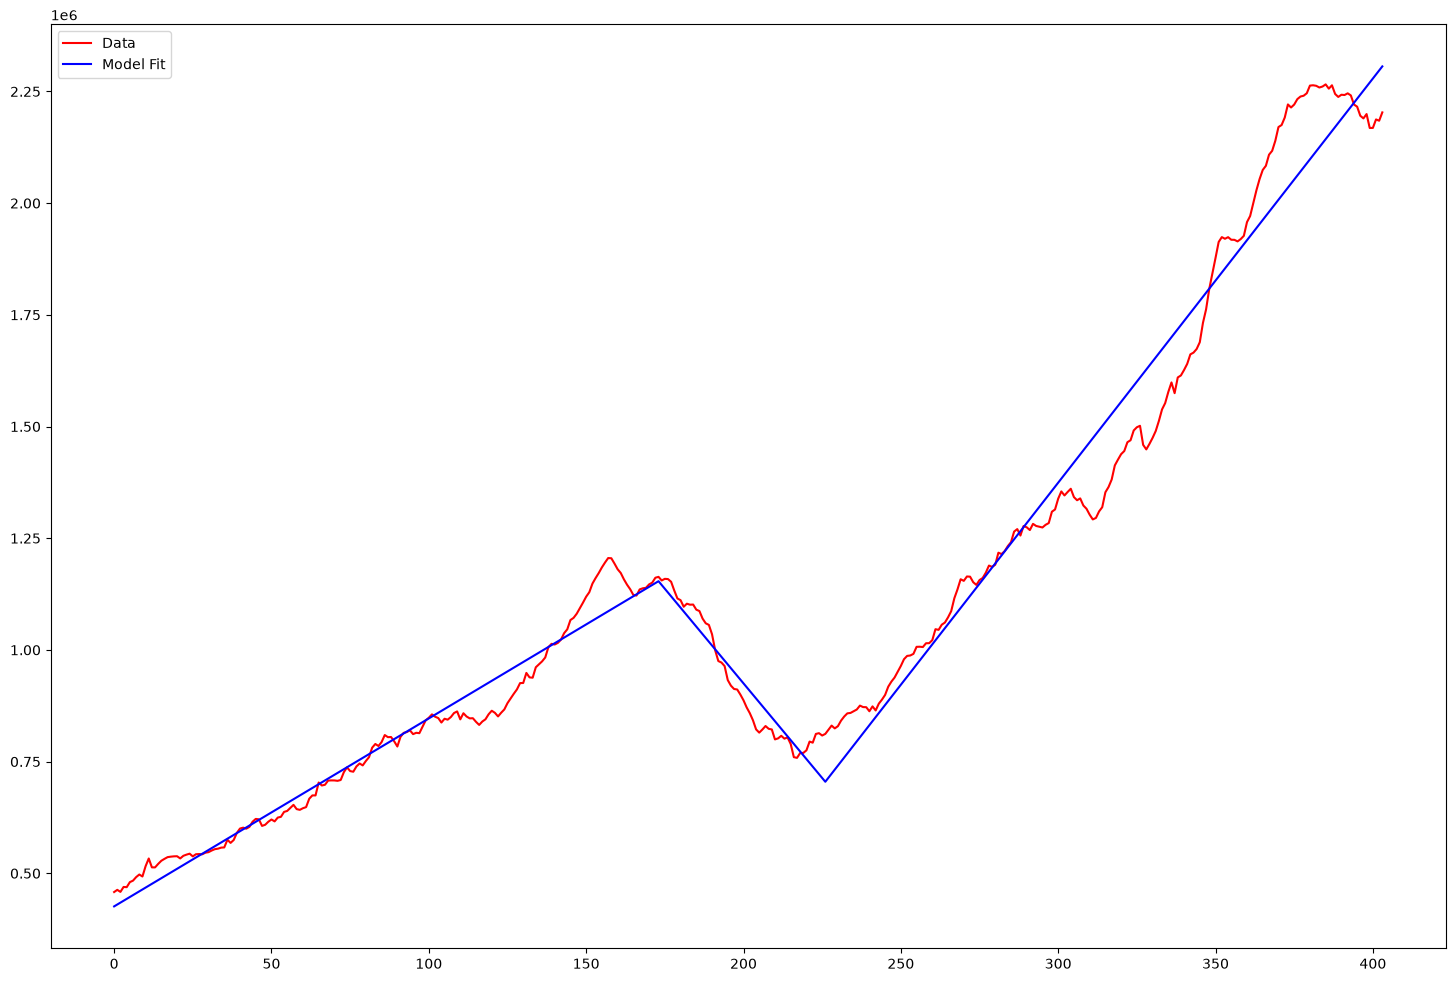

In [59]:
dm = np.zeros((n,4))
dm[:,0] = 1
dm[:,1] = t
dm[:,2] = np.maximum(t - s1_hat, 0)
dm[:,3] = np.maximum(t - s2_hat, 0)

model = sm.OLS(y, dm).fit()
beta = model.params
print(beta)

plt.figure(figsize=(18, 12))
plt.plot(t, y, color='red', label='Data')
plt.plot(t, dm@beta, color = 'blue', label='Model Fit')
plt.legend()
plt.show()

Part C

There are a few glaring issues with this fit. First it fails to capture any of the jumps we see in the actual data. While it does capture the gernal trend it is unreliable for some of the peaks. We also see that the line's inflection points seeming lag behind the visible shift. This is mostly evident on the change of slope for s2 where the change is noticibly after the reversal. With all this said I would say that this model is in appropriate for the data.